<a href="https://colab.research.google.com/github/hinnnk/Forecasting_3/blob/main/NEW_Forecasting_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting Project

# **DataSet1** [process] (importing from github)

In [ ]:
import pandas as pd

#GitHub URL for Dataset 1
url1 = "https://raw.githubusercontent.com/hinnnk/Forecasting_3/refs/heads/main/DatSet1_household_power_consumption.csv"

#Load the dataset
df1 = pd.read_csv(url1)

#Display rows
df1

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2016,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2016,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2016,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2016,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2016,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0
...,...,...,...,...,...,...,...,...,...
250479,8/6/2017,16:03:00,0.326,0.098,240.34,1.4,0,2,0.0
250480,8/6/2017,16:04:00,0.306,0.094,240.11,1.4,0,1,0.0
250481,8/6/2017,16:05:00,0.344,0.106,239.82,1.6,0,1,0.0
250482,8/6/2017,16:06:00,0.416,0.226,240.17,2,0,1,0.0


### Checking dataset size

In [ ]:
#Check the number of rows and columns
df1.shape

(250484, 9)

### Checking data types and structure

In [ ]:
#Display info about the dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250484 entries, 0 to 250483
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   250484 non-null  object 
 1   Time                   250484 non-null  object 
 2   Global_active_power    250484 non-null  object 
 3   Global_reactive_power  250484 non-null  object 
 4   Voltage                250484 non-null  object 
 5   Global_intensity       250484 non-null  object 
 6   Sub_metering_1         250484 non-null  object 
 7   Sub_metering_2         250484 non-null  object 
 8   Sub_metering_3         246750 non-null  float64
dtypes: float64(1), object(8)
memory usage: 17.2+ MB


### Check for duplicates (here there are none)

In [ ]:
#Check for duplicate rows
df1.duplicated().sum()

np.int64(0)

### Check for missing values in columns

In [ ]:
#Check for missing values in each column
df1.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,3734


### Look for ? values

In [ ]:
#Check how many '?' values are present in each column
(df1 == '?').sum()

,0
Date,0
Time,0
Global_active_power,3734
Global_reactive_power,3734
Voltage,3734
Global_intensity,3734
Sub_metering_1,3734
Sub_metering_2,3734
Sub_metering_3,0


### Check unique values in problematic columns

In [ ]:
#Check examples of values in Global_active_power
df1['Global_active_power'].value_counts().head(10)

,count
Global_active_power,
?,3734
0.216,2835
0.218,2713
0.22,2327
0.214,1993
0.222,1924
0.224,1699
0.314,1619
0.318,1581


### Find affected rows

In [ ]:
#Find rows where Global_active_power contains '?'
missing_rows = df1[df1['Global_active_power'] == '?']

#Display the first 10 affected rows
missing_rows.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,21/12/2016,11:23:00,?,?,?,?,?,?,NaN
6840,21/12/2016,11:24:00,?,?,?,?,?,?,NaN
19724,30/12/2016,10:08:00,?,?,?,?,?,?,NaN
19725,30/12/2016,10:09:00,?,?,?,?,?,?,NaN
41832,14/1/2017,18:36:00,?,?,?,?,?,?,NaN
61909,28/1/2017,17:13:00,?,?,?,?,?,?,NaN
98254,22/2/2017,22:58:00,?,?,?,?,?,?,NaN
98255,22/2/2017,22:59:00,?,?,?,?,?,?,NaN
142588,25/3/2017,17:52:00,?,?,?,?,?,?,NaN
190497,28/4/2017,0:21:00,?,?,?,?,?,?,NaN


### Check data range of the missing data

In [ ]:
#Check when the missing data starts and ends
print("First missing record:")
print(missing_rows[['Date', 'Time']].iloc[0])

print("\nLast missing record:")
print(missing_rows[['Date', 'Time']].iloc[-1])

First missing record:
Date    21/12/2016
Time      11:23:00
Name: 6839, dtype: object

Last missing record:
Date    6/6/2017
Time    21:56:00
Name: 247952, dtype: object


### Check if 3,734 rows have same missing pattern

In [ ]:
#Check the missing-value pattern in the affected rows
missing_rows.isnull().sum()

#Check '?' values in the affected rows
(missing_rows == '?').sum()

,0
Date,0
Time,0
Global_active_power,3734
Global_reactive_power,3734
Voltage,3734
Global_intensity,3734
Sub_metering_1,3734
Sub_metering_2,3734
Sub_metering_3,0


### Check whether missing records are consecutive

In [ ]:
#Check the gaps between rows containing missing measurements

missing_indices = missing_rows.index

gaps = missing_indices.to_series().diff()

print("Number of missing records:", len(missing_indices))
print("Number of consecutive missing records:", (gaps == 1).sum())
print("Largest gap between missing records:", gaps.max())

Number of missing records: 3734
Number of consecutive missing records: 3725
Largest gap between missing records: 47909.0


### Find consecutive missing blocks

In [ ]:
#Identify consecutive groups of missing records

groups = (missing_indices.to_series().diff() != 1).cumsum()

missing_blocks = missing_indices.to_series().groupby(groups).agg(['first', 'last', 'count'])

missing_blocks = missing_blocks.sort_values('count', ascending=False)

missing_blocks.head(10)

,first,last,count
7,190497,194219,3723
1,6839,6840,2
2,19724,19725,2
5,98254,98255,2
3,41832,41832,1
4,61909,61909,1
6,142588,142588,1
8,240590,240590,1
9,247952,247952,1


### Check the large missing block

In [ ]:
#Get the largest missing-data block
largest_block = missing_blocks.iloc[0]

#Get the original rows belonging to the largest block
large_missing = df1.loc[
    largest_block['first']:largest_block['last']
]

print("Number of missing records:", len(large_missing))

print("\nFirst missing timestamp:")
print(large_missing[['Date', 'Time']].iloc[0])

print("\nLast missing timestamp:")
print(large_missing[['Date', 'Time']].iloc[-1])

Number of missing records: 3723

First missing timestamp:
Date    28/4/2017
Time      0:21:00
Name: 190497, dtype: object

Last missing timestamp:
Date    30/4/2017
Time     14:23:00
Name: 194219, dtype: object


# **DataSet 1 - CLEANING**

In [ ]:
#Create a copy of the original dataset for cleaning
df1_clean = df1.copy()

#Check the shape
df1_clean.shape

(250484, 9)

### Convert ? to missing values

In [ ]:
#Replace '?' with NaN
df1_clean = df1_clean.replace('?', pd.NA)

#Check missing values again
df1_clean.isnull().sum()

,0
Date,0
Time,0
Global_active_power,3734
Global_reactive_power,3734
Voltage,3734
Global_intensity,3734
Sub_metering_1,3734
Sub_metering_2,3734
Sub_metering_3,3734


### Convert measurement columns to numeric ('?' converted to missing vlaues, now converting the measurement columns from object to numeric [float64])

In [ ]:
#Columns that should contain numerical measurements
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

#Convert the measurement columns to numeric
df1_clean[numeric_columns] = df1_clean[numeric_columns].apply(
    pd.to_numeric, errors='coerce'
)

# Check the data types
df1_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250484 entries, 0 to 250483
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   250484 non-null  object 
 1   Time                   250484 non-null  object 
 2   Global_active_power    246750 non-null  float64
 3   Global_reactive_power  246750 non-null  float64
 4   Voltage                246750 non-null  float64
 5   Global_intensity       246750 non-null  float64
 6   Sub_metering_1         246750 non-null  float64
 7   Sub_metering_2         246750 non-null  float64
 8   Sub_metering_3         246750 non-null  float64
dtypes: float64(7), object(2)
memory usage: 17.2+ MB


### Create 'datetime' column

In [ ]:
#Combine Date and Time into a single datetime column
df1_clean['datetime'] = pd.to_datetime(
    df1_clean['Date'] + ' ' + df1_clean['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

# Display the result
df1_clean[['Date', 'Time', 'datetime']].head()

,Date,Time,datetime
0,16/12/2016,17:24:00,2016-12-16 17:24:00
1,16/12/2016,17:25:00,2016-12-16 17:25:00
2,16/12/2016,17:26:00,2016-12-16 17:26:00
3,16/12/2016,17:27:00,2016-12-16 17:27:00
4,16/12/2016,17:28:00,2016-12-16 17:28:00


### Check timestamps

In [ ]:
#Sort the dataset chronologically
df1_clean = df1_clean.sort_values('datetime').reset_index(drop=True)

#Check the first and last timestamps
print("First timestamp:")
print(df1_clean['datetime'].iloc[0])

print("\nLast timestamp:")
print(df1_clean['datetime'].iloc[-1])

First timestamp:
2016-12-16 17:24:00

Last timestamp:
2017-06-08 16:07:00


### Check for duplicated timestamps (2 rows could have diff measurements but have same timestamps = problem) - there are none but good to check

In [ ]:
#Check for duplicate timestamps
duplicate_timestamps = df1_clean['datetime'].duplicated().sum()

print("Duplicate timestamps:", duplicate_timestamps)

Duplicate timestamps: 0


### Remove the large missing block

In [ ]:
#Define the large missing-data period
large_gap_start = pd.Timestamp('2017-04-28 00:21:00')
large_gap_end = pd.Timestamp('2017-04-30 14:23:00')

#Remove the large missing-data period
df1_clean = df1_clean[
    ~df1_clean['datetime'].between(large_gap_start, large_gap_end)
].copy()

# Check the new dataset size
print("Rows after removing large missing block:", len(df1_clean))

Rows after removing large missing block: 246761


### Interpolate (introduce, add) the short missing gaps

In [ ]:
#Interpolate short missing gaps
df1_clean[numeric_columns] = df1_clean[numeric_columns].interpolate(
    method='linear'
)

#Check remaining missing values
df1_clean[numeric_columns].isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


### Final Data quality check

In [ ]:
#Final data quality checks after cleaning

print("Dataset shape:", df1_clean.shape)

print("\nMissing values:")
print(df1_clean.isnull().sum())

print("\nDuplicate rows:", df1_clean.duplicated().sum())

print("\nDuplicate timestamps:",
      df1_clean['datetime'].duplicated().sum())

print("\nData types:")
print(df1_clean.dtypes)

Dataset shape: (246761, 10)

Missing values:
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
datetime                 0
dtype: int64

Duplicate rows: 0

Duplicate timestamps: 0

Data types:
Date                             object
Time                             object
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
datetime                 datetime64[ns]
dtype: object


### Set 'datetime' as index

In [ ]:
#Set datetime as the DataFrame index
df1_clean = df1_clean.set_index('datetime')

#Display the first few rows
df1_clean.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2016-12-16 17:24:00,16/12/2016,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2016-12-16 17:25:00,16/12/2016,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2016-12-16 17:26:00,16/12/2016,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2016-12-16 17:27:00,16/12/2016,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2016-12-16 17:28:00,16/12/2016,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### Aggregate to hourly data

In [ ]:
#Aggregate the minute-level data into hourly averages + rounding to 2 decimal points
df1_hourly = df1_clean[numeric_columns].resample('h').mean().round(2)

#Display the first few hourly observations (there are 4000 ~)
df1_hourly.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2016-12-16 17:00:00,4.22,0.23,234.64,18.10,0.0,0.53,16.86
2016-12-16 18:00:00,3.63,0.08,234.58,15.60,0.0,6.72,16.87
2016-12-16 19:00:00,3.40,0.09,233.23,14.50,0.0,1.43,16.68
2016-12-16 20:00:00,3.27,0.08,234.07,13.92,0.0,0.00,16.78
2016-12-16 21:00:00,3.06,0.08,237.16,13.05,0.0,0.42,17.22


### Check the hourly dataset

In [ ]:
#Check the hourly dataset
df1_hourly.info()

print("\nMissing values:")
print(df1_hourly.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4176 entries, 0 to 4175
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   level_0                4176 non-null   int64         
 1   index                  4176 non-null   int64         
 2   datetime               4176 non-null   datetime64[ns]
 3   Global_active_power    4115 non-null   float64       
 4   Global_reactive_power  4115 non-null   float64       
 5   Voltage                4115 non-null   float64       
 6   Global_intensity       4115 non-null   float64       
 7   Sub_metering_1         4115 non-null   float64       
 8   Sub_metering_2         4115 non-null   float64       
 9   Sub_metering_3         4115 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(2)
memory usage: 326.4 KB

Missing values:
level_0                   0
index                     0
datetime                  0
Global_active

### Make the hourly dataset easier to work with

In [ ]:
#Recreate the hourly dataset from the cleaned minute-level dataset
df1_hourly = df1_clean[numeric_columns].resample('h').mean()

#Remove completely empty hourly rows
df1_hourly = df1_hourly.dropna(
    subset=numeric_columns,
    how='all'
).copy()

#Reset the datetime index ONCE + rounding the decimals
df1_hourly = df1_hourly.reset_index().round(2)

#Display the cleaned hourly dataset
df1_hourly.head()

,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2016-12-16 17:00:00,4.22,0.23,234.64,18.10,0.0,0.53,16.86
1,2016-12-16 18:00:00,3.63,0.08,234.58,15.60,0.0,6.72,16.87
2,2016-12-16 19:00:00,3.40,0.09,233.23,14.50,0.0,1.43,16.68
3,2016-12-16 20:00:00,3.27,0.08,234.07,13.92,0.0,0.00,16.78
4,2016-12-16 21:00:00,3.06,0.08,237.16,13.05,0.0,0.42,17.22


In [ ]:
#Final check
print("Dataset shape:", df1_hourly.shape)

print("\nMissing values:")
print(df1_hourly[numeric_columns].isnull().sum())

print("\nColumns:")
print(df1_hourly.columns.tolist())

Dataset shape: (4115, 8)

Missing values:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

Columns:
['datetime', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


## Saving the **CLEANED** DataSet (this saves to colab files)

In [ ]:
# Save the cleaned Dataset 1
output_file = '/content/Dataset1_CLEANED_household_power_consumption_hourly.csv'

df1_hourly.to_csv(output_file, index=False)

print("File saved to:")
print(output_file)

File saved to:
/content/Dataset1_CLEANED_household_power_consumption_hourly.csv


### Running this will save to own device

In [ ]:
from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **DataSet 2** [process]

In [ ]:
import pandas as pd

#GitHub URL for Dataset 2
url2 = "https://raw.githubusercontent.com/hinnnk/Forecasting_3/refs/heads/main/DataSet2_household_power_consumption.csv"

#Load Dataset 2
df2 = pd.read_csv(url2)

# Display the dataset
df2

,index,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0,1/1/07,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,1,1/1/07,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,2,1/1/07,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,3,1/1/07,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,4,1/1/07,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...
260635,260635,30/6/2007,23:55:00,2.88,0.36,239.01,12,0,0,18.0
260636,260636,30/6/2007,23:56:00,2.892,0.358,238.86,12.2,0,0,17.0
260637,260637,30/6/2007,23:57:00,2.882,0.28,239.05,12,0,0,18.0
260638,260638,30/6/2007,23:58:00,2.66,0.29,238.98,11.2,0,0,18.0


### Inspecting DataSet structure (safe to remove)

In [ ]:
print("Dataset shape:", df2.shape)

print("\nColumn information:")
df2.info()

Dataset shape: (260640, 10)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  260640 non-null  int64  
 1   Date                   260640 non-null  object 
 2   Time                   260640 non-null  object 
 3   Global_active_power    260640 non-null  object 
 4   Global_reactive_power  260640 non-null  object 
 5   Voltage                260640 non-null  object 
 6   Global_intensity       260640 non-null  object 
 7   Sub_metering_1         260640 non-null  object 
 8   Sub_metering_2         260640 non-null  object 
 9   Sub_metering_3         256869 non-null  float64
dtypes: float64(1), int64(1), object(8)
memory usage: 19.9+ MB


### Check missing values and duplicates (safe to remove)

In [ ]:
print("Missing values:")
print(df2.isnull().sum())

print("\nDuplicate rows:", df2.duplicated().sum())

Missing values:
index                       0
Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           3771
dtype: int64

Duplicate rows: 0


### Check for invalid ? values (safe to remove)

In [ ]:
#Check for '?' values in the dataset
print("Number of '?' values in each column:")
print((df2 == '?').sum())

Number of '?' values in each column:
index                       0
Date                        0
Time                        0
Global_active_power      3771
Global_reactive_power    3771
Voltage                  3771
Global_intensity         3771
Sub_metering_1           3771
Sub_metering_2           3771
Sub_metering_3              0
dtype: int64


### Investigate missing records (safe to remove)

In [ ]:
#Find rows where Global_active_power contains '?'
missing_rows2 = df2[df2['Global_active_power'] == '?']

#Display the first 10 affected rows
missing_rows2.head(10)

#---------------

# Check the first and last missing timestamps
print("First missing record:")
print(missing_rows2[['Date', 'Time']].iloc[0])

print("\nLast missing record:")
print(missing_rows2[['Date', 'Time']].iloc[-1])

print("\nNumber of missing records:", len(missing_rows2))

First missing record:
Date    14/1/2007
Time     18:36:00
Name: 19836, dtype: object

Last missing record:
Date    29/6/2007
Time      9:59:00
Name: 258359, dtype: object

Number of missing records: 3771


### Analyse missing data blocks

In [ ]:
#Get the row indexes of missing records
missing_indices2 = missing_rows2.index

#Calculate the gaps between missing records
gaps2 = missing_indices2.to_series().diff()

print("Number of missing records:", len(missing_indices2))
print("Number of consecutive missing records:", (gaps2 == 1).sum())
print("Largest gap between missing records:", gaps2.max())

Number of missing records: 3771
Number of consecutive missing records: 3758
Largest gap between missing records: 47909.0


### Identify the missing blocks

In [ ]:
#Group consecutive missing records into blocks
groups2 = (missing_indices2.to_series().diff() != 1).cumsum()

missing_blocks2 = (
    missing_indices2
    .to_series()
    .groupby(groups2)
    .agg(['first', 'last', 'count'])
)

#Sort from largest to smallest
missing_blocks2 = missing_blocks2.sort_values('count', ascending=False)

#Display the largest missing blocks
missing_blocks2.head(10)

,first,last,count
5,168501,172223,3723
11,230039,230071,33
10,230035,230037,3
3,76258,76259,2
12,244094,244095,2
4,120592,120592,1
2,39913,39913,1
1,19836,19836,1
6,218594,218594,1
9,229685,229685,1


### Find the large missing block (safe to remove)

In [ ]:
#Get the largest missing-data block
largest_block2 = missing_blocks2.iloc[0]

#Get the corresponding row indexes
large_gap_start_index2 = int(largest_block2['first'])
large_gap_end_index2 = int(largest_block2['last'])

#Display the date and time of the large missing block
print("Large missing block:")
print("Start index:", large_gap_start_index2)
print("End index:", large_gap_end_index2)

print("\nStart date/time:")
print(df2.loc[large_gap_start_index2, ['Date', 'Time']])

print("\nEnd date/time:")
print(df2.loc[large_gap_end_index2, ['Date', 'Time']])

print("\nNumber of missing records:")
print(int(largest_block2['count']))


Large missing block:
Start index: 168501
End index: 172223

Start date/time:
Date    28/4/2007
Time      0:21:00
Name: 168501, dtype: object

End date/time:
Date    30/4/2007
Time     14:23:00
Name: 172223, dtype: object

Number of missing records:
3723


# **DataSet 2 - CLEANING**

### Create a clean copy

In [ ]:
#Create a copy of the original Dataset 2 for cleaning
df2_clean = df2.copy()

#Check the shape
print("Original Dataset 2 shape:", df2.shape)
print("Clean Dataset 2 shape:", df2_clean.shape)

Original Dataset 2 shape: (260640, 10)
Clean Dataset 2 shape: (260640, 10)


### Replace ? with missing value

In [ ]:
#Replace '?' with missing values
df2_clean = df2_clean.replace('?', pd.NA)

#Check the missing values again
print("Missing values after replacing '?':")
print(df2_clean.isnull().sum())

Missing values after replacing '?':
index                       0
Date                        0
Time                        0
Global_active_power      3771
Global_reactive_power    3771
Voltage                  3771
Global_intensity         3771
Sub_metering_1           3771
Sub_metering_2           3771
Sub_metering_3           3771
dtype: int64


### Convert measurement columns to numeric

In [ ]:
#Columns that contain numerical measurements
numeric_columns2 = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

#Convert the measurement columns to numeric
df2_clean[numeric_columns2] = df2_clean[numeric_columns2].apply(
    pd.to_numeric,
    errors='coerce'
)

#Check the data types
df2_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  260640 non-null  int64  
 1   Date                   260640 non-null  object 
 2   Time                   260640 non-null  object 
 3   Global_active_power    256869 non-null  float64
 4   Global_reactive_power  256869 non-null  float64
 5   Voltage                256869 non-null  float64
 6   Global_intensity       256869 non-null  float64
 7   Sub_metering_1         256869 non-null  float64
 8   Sub_metering_2         256869 non-null  float64
 9   Sub_metering_3         256869 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 19.9+ MB


### Create 'datetime' column

In [ ]:
#Combine Date and Time into a single datetime column
df2_clean['datetime'] = pd.to_datetime(
    df2_clean['Date'] + ' ' + df2_clean['Time'],
    dayfirst=True,
    format='mixed'
)

#Display the result
df2_clean[['Date', 'Time', 'datetime']].head()


,Date,Time,datetime
0,1/1/07,0:00:00,2007-01-01 00:00:00
1,1/1/07,0:01:00,2007-01-01 00:01:00
2,1/1/07,0:02:00,2007-01-01 00:02:00
3,1/1/07,0:03:00,2007-01-01 00:03:00
4,1/1/07,0:04:00,2007-01-01 00:04:00


### Sort chronologically

In [ ]:
#Sort Dataset 2 chronologically
df2_clean = df2_clean.sort_values('datetime').reset_index(drop=True)

#Check the first and last timestamps
print("First timestamp:")
print(df2_clean['datetime'].iloc[0])

print("\nLast timestamp:")
print(df2_clean['datetime'].iloc[-1])

First timestamp:
2007-01-01 00:00:00

Last timestamp:
2007-06-30 23:59:00


### Check duplicate timestamps (safe to remove)

In [ ]:
#Check for duplicate timestamps
duplicate_timestamps2 = df2_clean['datetime'].duplicated().sum()

print("Duplicate timestamps:", duplicate_timestamps2)

Duplicate timestamps: 0


### Remove unnecessary 'index' column

In [ ]:
#Remove the original index column
df2_clean = df2_clean.drop(columns=['index'])

#Display the remaining columns
print(df2_clean.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'datetime'],
      dtype='object')


### Remove the large missing period

In [ ]:
#Define the large missing period
large_gap_start2 = pd.Timestamp('2007-04-28 00:21:00')
large_gap_end2 = pd.Timestamp('2007-04-30 14:23:00')

#Remove the large missing period
df2_clean = df2_clean[
    ~df2_clean['datetime'].between(large_gap_start2, large_gap_end2)
].copy()

#Check the new dataset size
print("Dataset 2 shape after removing large missing period:", df2_clean.shape)

Dataset 2 shape after removing large missing period: (256917, 10)


### Interplate the remaining short gaps

In [ ]:
#Interpolate the remaining short missing gaps
df2_clean[numeric_columns2] = df2_clean[numeric_columns2].interpolate(method='linear')

#Check remaining missing values
print("Remaining missing values:")
print(df2_clean[numeric_columns2].isnull().sum())

Remaining missing values:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


### Set 'datetime' as the index

In [ ]:
#Set datetime as the index
df2_clean = df2_clean.set_index('datetime')

#Check the first few rows
df2_clean.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2007-01-01 00:00:00,1/1/07,0:00:00,2.580,0.136,241.97,10.6,0.0,0.0,0.0
2007-01-01 00:01:00,1/1/07,0:01:00,2.552,0.100,241.75,10.4,0.0,0.0,0.0
2007-01-01 00:02:00,1/1/07,0:02:00,2.550,0.100,241.64,10.4,0.0,0.0,0.0
2007-01-01 00:03:00,1/1/07,0:03:00,2.550,0.100,241.71,10.4,0.0,0.0,0.0
2007-01-01 00:04:00,1/1/07,0:04:00,2.554,0.100,241.98,10.4,0.0,0.0,0.0


### Remove the old 'Date' and 'Time' columns

In [ ]:
#Remove the original Date and Time columns
df2_clean = df2_clean.drop(columns=['Date', 'Time'])

#Display the remaining columns
print(df2_clean.columns)

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


### Resample to hourly averages

In [ ]:
#Resample the minute-level data into hourly averages
df2_hourly = df2_clean[numeric_columns2].resample('h').mean().round(2)

#Display the first few hourly records
df2_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2007-01-01 00:00:00,2.55,0.11,241.36,10.53,0.0,0.58,0.0
2007-01-01 01:00:00,2.52,0.07,241.10,10.44,0.0,0.00,0.0
2007-01-01 02:00:00,2.58,0.11,243.20,10.54,0.0,0.33,0.0
2007-01-01 03:00:00,2.54,0.09,243.27,10.40,0.0,0.27,0.0
2007-01-01 04:00:00,2.48,0.09,242.46,10.11,0.0,0.00,0.0


### Check for empty hourly periods (safe to remove)

In [ ]:
#Check for hourly rows where all measurements are missing
empty_hours2 = df2_hourly.isnull().all(axis=1).sum()

print("Completely empty hourly rows:", empty_hours2)

Completely empty hourly rows: 61


### Remove completely empty hourly rows

In [ ]:
#Remove hourly rows where all measurements are missing
df2_hourly = df2_hourly.dropna(how='all')

#Check the new dataset size
print("Dataset 2 hourly shape:", df2_hourly.shape)

Dataset 2 hourly shape: (4283, 7)


### Finall missing value check (safe to remove)

In [ ]:
#Check for remaining missing values
print("Remaining missing values:")
print(df2_hourly.isnull().sum())

Remaining missing values:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


### Check final dataset structure (safe to remove)

In [ ]:
#Check the final dataset structure
print("Dataset 2 shape:", df2_hourly.shape)

print("\nColumns:")
print(df2_hourly.columns.tolist())

print("\nData types:")
print(df2_hourly.dtypes)

Dataset 2 shape: (4283, 7)

Columns:
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Data types:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


### Final timestamp check

In [ ]:
#Check the first and last timestamps of the cleaned dataset
print("First timestamp:", df2_hourly.index.min())
print("Last timestamp:", df2_hourly.index.max())

First timestamp: 2007-01-01 00:00:00
Last timestamp: 2007-06-30 23:00:00


## Save **CLEANED** DataSet (will save to colab files)

In [ ]:
#Convert datetime index back into a column
df2_final = df2_hourly.reset_index()

#Round values to 2 decimal places
df2_final = df2_final.round(2)

#Save the cleaned Dataset 2
output_file2 = 'Dataset2_CLEANED_household_power_consumption_hourly.csv'

df2_final.to_csv(output_file2, index=False)

print("Dataset 2 saved successfully as:")
print(output_file2)

print("\nFinal shape:", df2_final.shape)

NameError: name 'df2_hourly' is not defined

### Running this will save to own device

In [ ]:
from google.colab import files

files.download('Dataset2_CLEANED_household_power_consumption_hourly.csv')

FileNotFoundError: Cannot find file: Dataset2_CLEANED_household_power_consumption_hourly.csv

# XGBoost (Dataset 1)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [ ]:
url2 = "https://raw.githubusercontent.com/hinnnk/Forecasting_3/refs/heads/main/Dataset1_CLEANED_household_power_consumption_hourly.csv"
df = pd.read_csv(url2)
df.dtypes
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')
df.index = pd.to_datetime(df.index)

<Axes: title={'center': 'energy use'}, xlabel='datetime'>

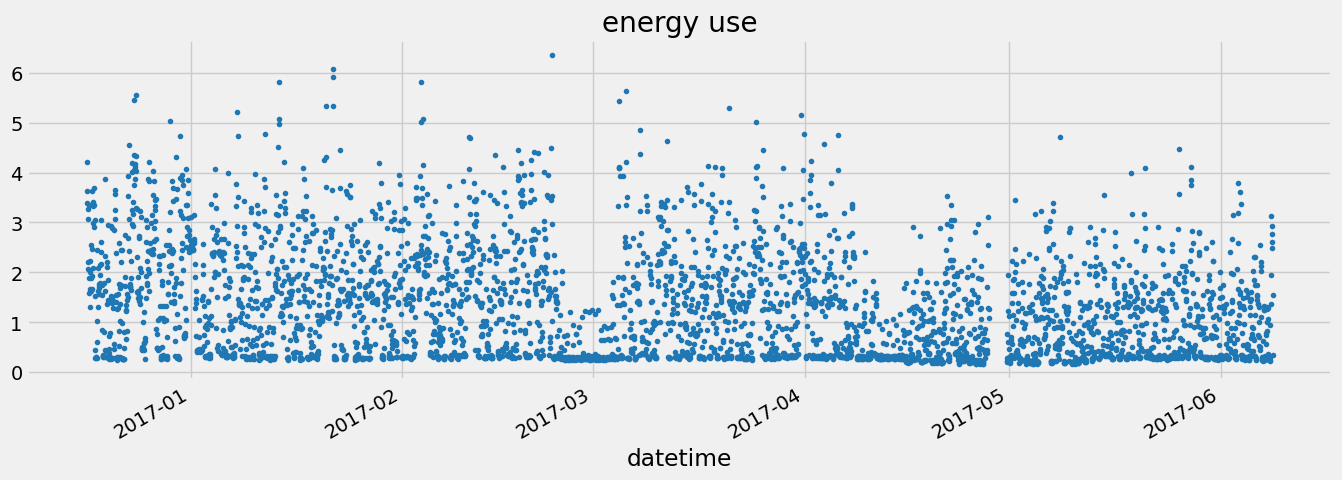

In [ ]:
df['Global_active_power'].plot(style='.', figsize=(15, 5), color=color_pal[0], title='energy use')

## Train/ Test

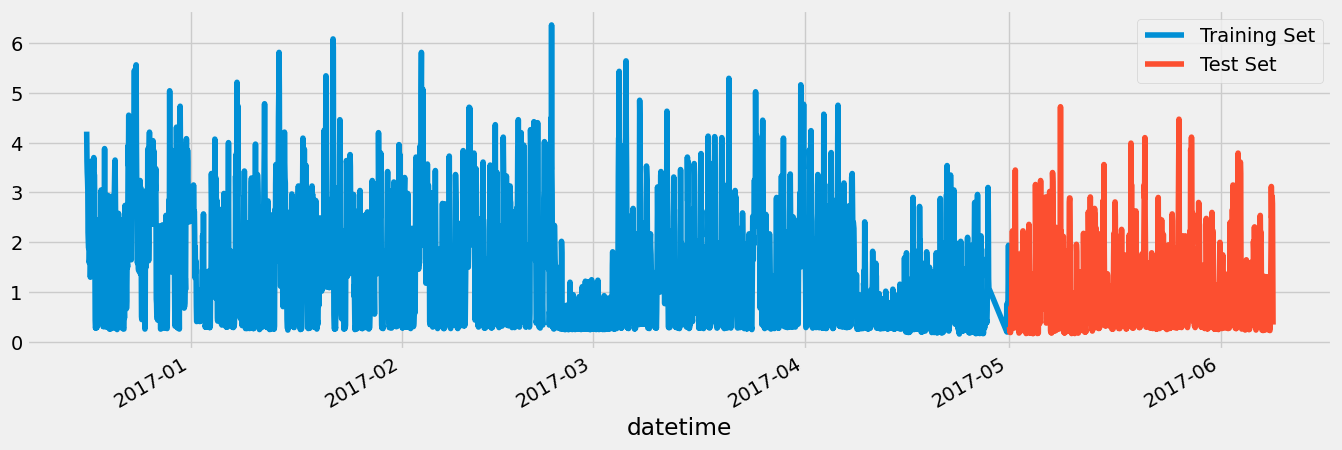

In [ ]:
from matplotlib import axes
train = df.loc[df.index < '05-01-2017']
test = df.loc[df.index >= '05-01-2017']

fig, axes = plt.subplots(figsize=(15,5))
train['Global_active_power'].plot(ax=axes, label="Training Set")
test['Global_active_power'].plot(ax=axes, label="Test Set")
axes.legend(['Training Set', 'Test Set'])
plt.show()

#Feature Creation

In [ ]:
def create_features(df):
    """
    Create time series features based on time series index
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['date'] = df.index.date
    df['day'] = df.index.day
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df
df = create_features(df)


#Visualise Features/ Target Relationship

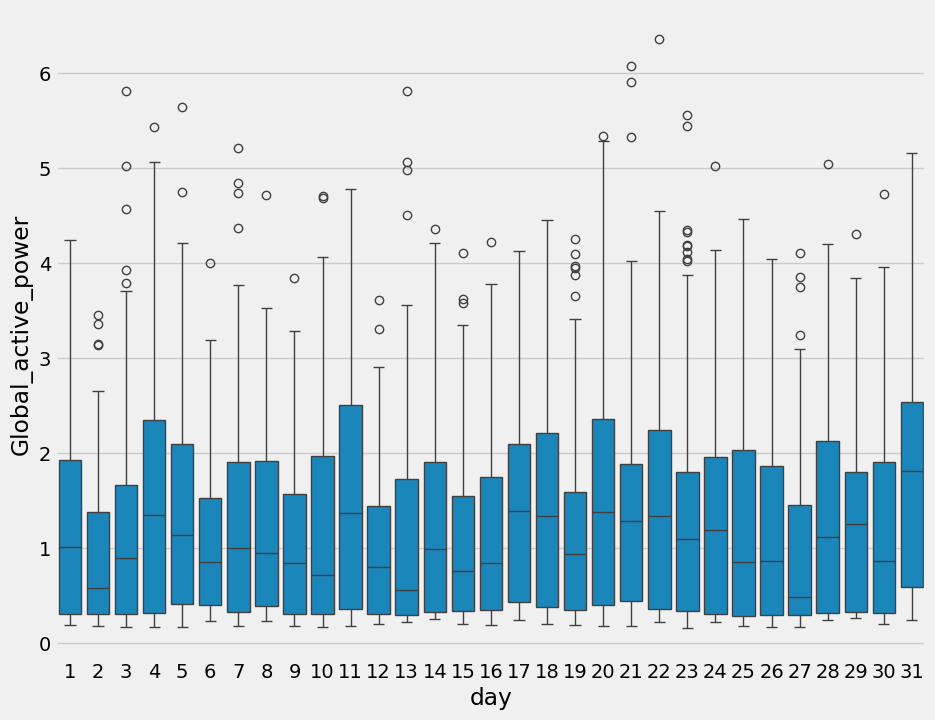

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(data = df, x = 'day', y = 'Global_active_power')
plt.show()

#Create Model

In [ ]:
train = create_features(train)
test = create_features(test)

FEATURES = ['hour', 'dayofweek', 'quarter', 'day', 'month', 'year', 'dayofyear']
TARGET = 'Global_active_power'

In [ ]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [ ]:
reg = xgb.XGBRegressor(n_estimators = 1000, early_stopping_rounds = 50, learning_rate = 0.05, max_depth = 5, subsample = 0.8)
reg.fit(X_train, y_train, eval_set = [(X_train, y_train), (X_test, y_test)], verbose = True)

[0]	validation_0-rmse:1.09805	validation_1-rmse:0.88053
[1]	validation_0-rmse:1.07772	validation_1-rmse:0.86461
[2]	validation_0-rmse:1.05998	validation_1-rmse:0.85482
[3]	validation_0-rmse:1.04331	validation_1-rmse:0.84294
[4]	validation_0-rmse:1.02779	validation_1-rmse:0.82972
[5]	validation_0-rmse:1.01123	validation_1-rmse:0.81541
[6]	validation_0-rmse:0.99741	validation_1-rmse:0.80493
[7]	validation_0-rmse:0.98333	validation_1-rmse:0.79372
[8]	validation_0-rmse:0.97066	validation_1-rmse:0.78433
[9]	validation_0-rmse:0.95811	validation_1-rmse:0.77727
[10]	validation_0-rmse:0.94710	validation_1-rmse:0.77155
[11]	validation_0-rmse:0.93675	validation_1-rmse:0.76585
[12]	validation_0-rmse:0.92648	validation_1-rmse:0.75738
[13]	validation_0-rmse:0.91674	validation_1-rmse:0.74962
[14]	validation_0-rmse:0.90751	validation_1-rmse:0.74342
[15]	validation_0-rmse:0.89963	validation_1-rmse:0.73689
[16]	validation_0-rmse:0.89115	validation_1-rmse:0.73074
[17]	validation_0-rmse:0.88201	validation

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

#Feature Importance

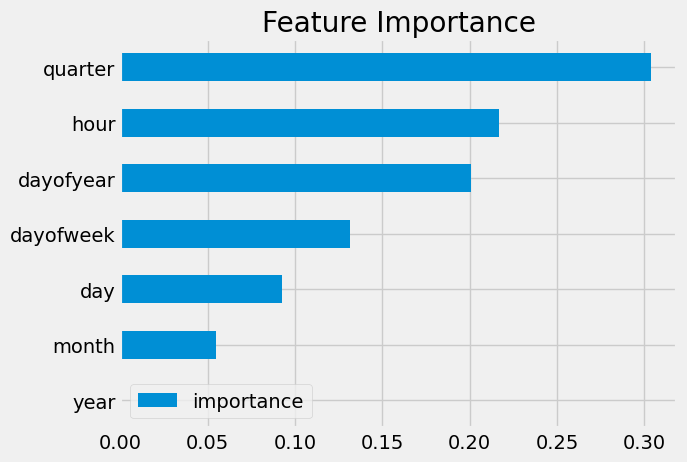

In [ ]:
fi = pd.DataFrame(data = reg.feature_importances_, index = reg.feature_names_in_, columns = ['importance'])
fi.sort_values('importance').plot(kind = 'barh', title = 'Feature Importance')
plt.show()

#Forecasting Test

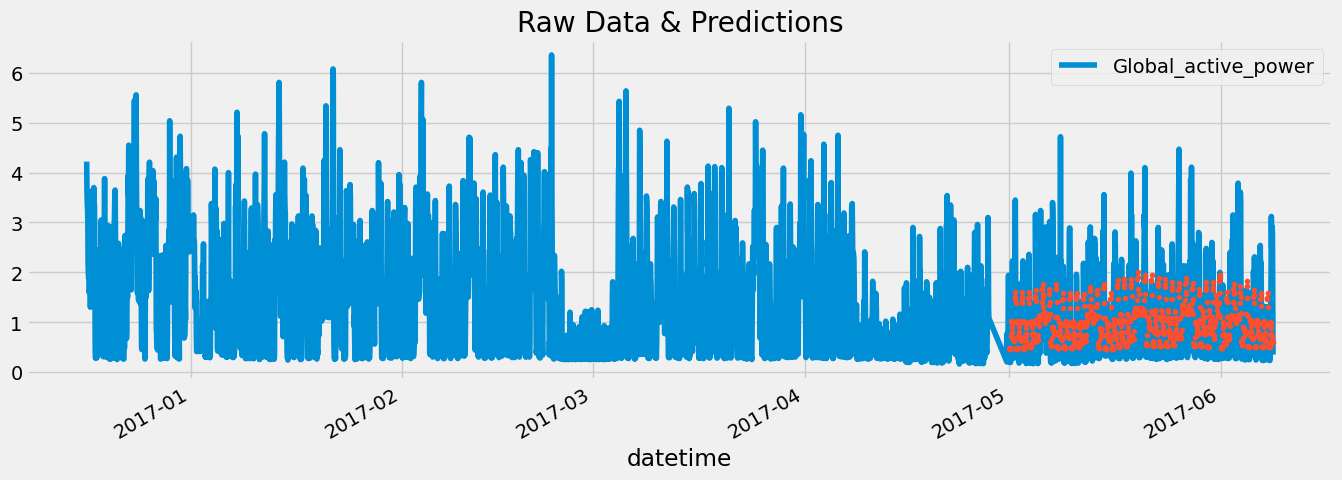

In [ ]:
df = df.drop(columns = [c for c in df.columns if 'prediction' in c], errors = 'ignore')

test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how = 'left', left_index = True, right_index = True)

ax = df[['Global_active_power']].plot(figsize=(15,5))
df['prediction'].plot(ax=ax, style = '.')
ax.set_title('Raw Data & Predictions')
plt.show()

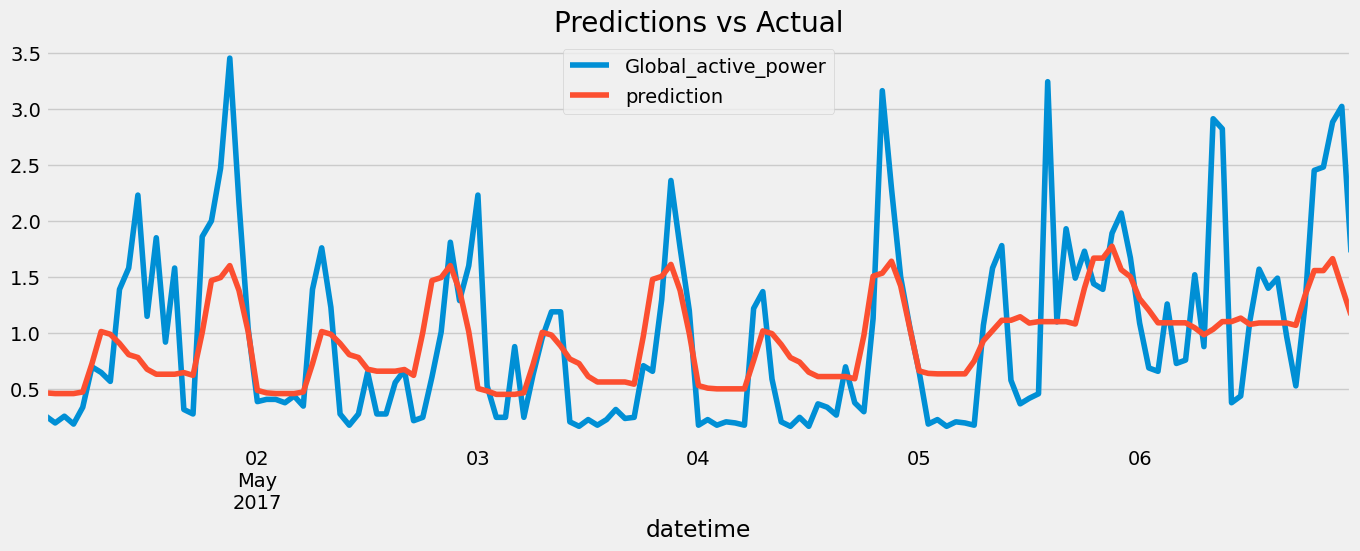

In [ ]:
ax=df.loc[(df.index > '2017-05-01') & (df.index < '2017-05-7'), ['Global_active_power', 'prediction']].plot(figsize=(15,5), title='Predictions vs Actual')
plt.show()

#Calculate Error
- worst + best predictions

In [ ]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby('date')['error'].mean().sort_values(ascending = False).head(10)

,error
date,
2017-05-27,0.916079
2017-06-08,0.887393
2017-06-03,0.792969
2017-05-13,0.699109
2017-05-20,0.678693
2017-05-07,0.676025
2017-05-31,0.657671
2017-06-02,0.622774
2017-05-06,0.615702


# Linear Regression (Dataset 1)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
url2 = "https://raw.githubusercontent.com/hinnnk/Forecasting_3/refs/heads/main/Dataset1_CLEANED_household_power_consumption_hourly.csv"
df = pd.read_csv(url2)
df.dtypes
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

#Train/Test

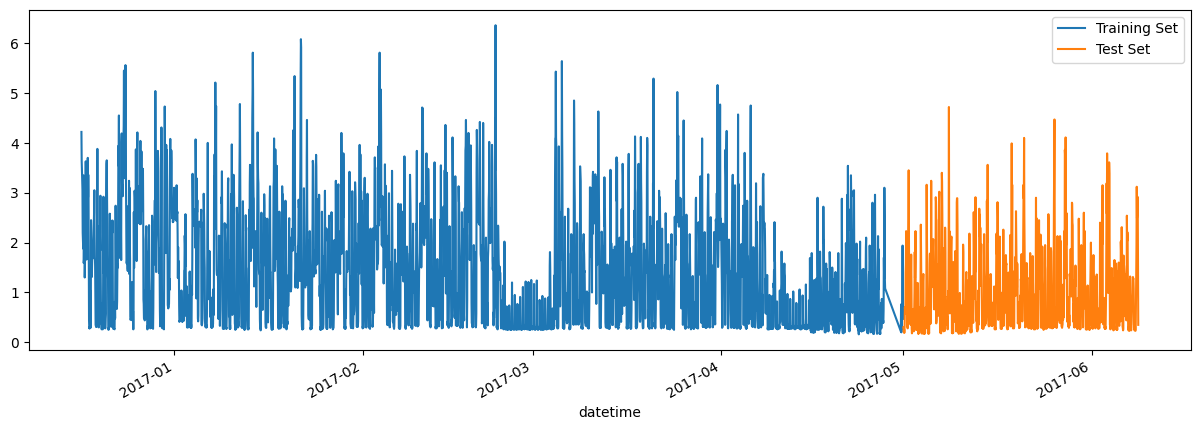

In [ ]:
from matplotlib import axes
train = df.loc[df.index < '05-01-2017']
test = df.loc[df.index >= '05-01-2017']

fig, axes = plt.subplots(figsize=(15,5))
train['Global_active_power'].plot(ax=axes, label="Training Set")
test['Global_active_power'].plot(ax=axes, label="Test Set")
axes.legend(['Training Set', 'Test Set'])
plt.show()

#Feature Creation

In [ ]:
def create_features(df):
    """
    Create time series features based on time series index
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['date'] = df.index.date
    df['day'] = df.index.day
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df
df = create_features(df)

#Visualise Features

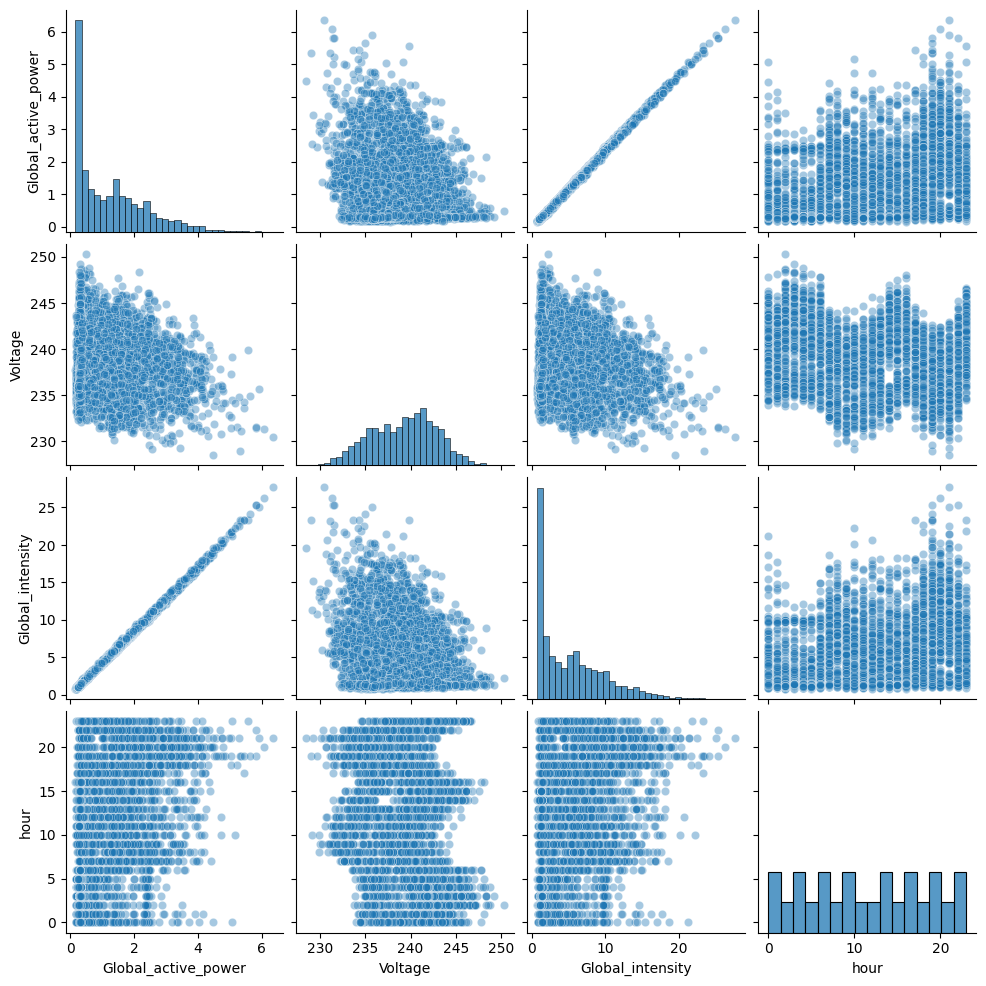

In [ ]:
sns.pairplot(df[['Global_active_power', 'Voltage', 'Global_intensity', 'hour']], kind='scatter', plot_kws={'alpha': 0.4})

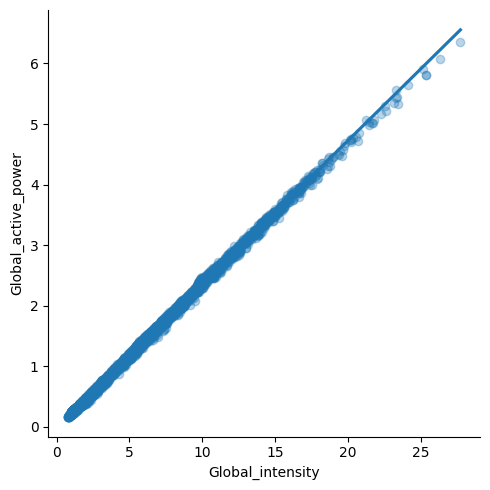

In [ ]:
sns.lmplot(x='Global_intensity', y='Global_active_power', data=df, scatter_kws={'alpha': 0.3})

#Training Linear Regression

In [ ]:
train = create_features(train)
test = create_features(test)

FEATURES = ['hour', 'dayofweek', 'quarter', 'day', 'month', 'year', 'dayofyear']
TARGET = 'Global_active_power'

In [ ]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

cdf = pd.DataFrame(lin_reg.coef_, X_train.columns, columns=['Coefficient'])
print(cdf)

           Coefficient
hour          0.052441
dayofweek     0.069729
quarter      -0.284586
day           0.022212
month         0.668965
year         -2.778576
dayofyear    -0.026610


#Predictions

In [ ]:
y_pred = lin_reg.predict(X_test)

print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

test['prediction_linreg'] = y_pred

R-squared: 0.06572811013745639
RMSE: 0.7808586052668541


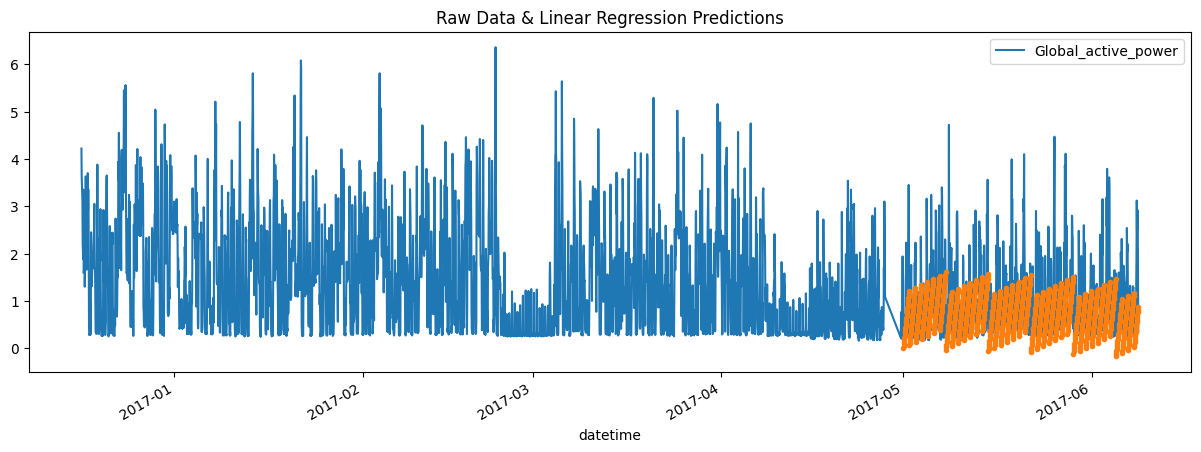

In [ ]:
df = df.drop(columns=[c for c in df.columns if 'prediction' in c], errors='ignore')
test['prediction'] = lin_reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['Global_active_power']].plot(figsize=(15,5))
df['prediction'].plot(ax=ax, style='.')
ax.set_title('Raw Data & Linear Regression Predictions')
plt.show()

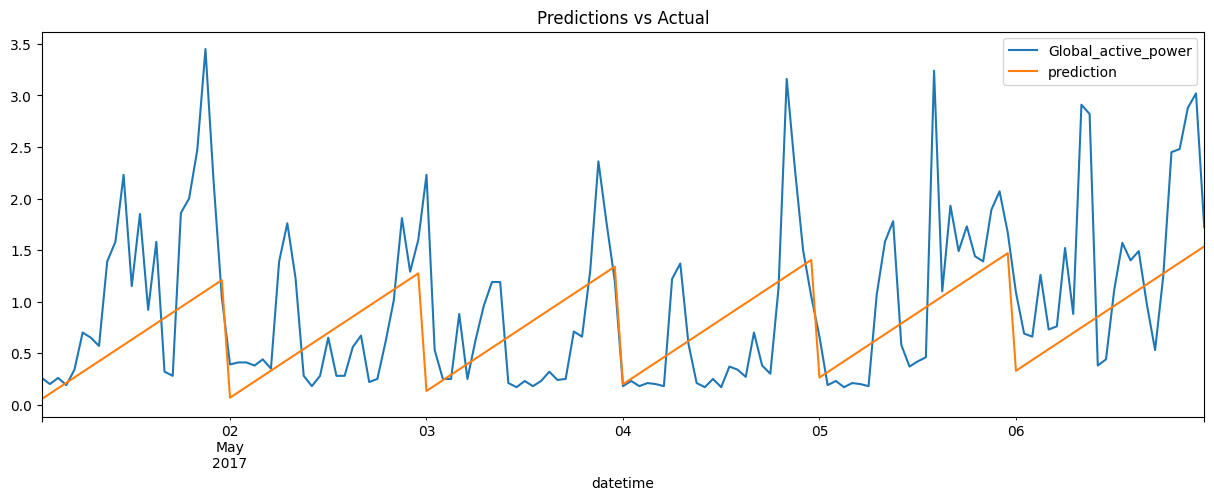

In [ ]:
ax=df.loc[(df.index > '2017-05-01') & (df.index < '2017-05-7'), ['Global_active_power', 'prediction']].plot(figsize=(15,5), title='Predictions vs Actual')
plt.show()

In [ ]:
test['error'] = np.abs(test[TARGET] - test['prediction_linreg'])
test['date'] = test.index.date
test.groupby('date')['error'].mean().sort_values(ascending=False).head(10)

,error
date,
2017-06-08,0.919186
2017-05-25,0.804795
2017-05-27,0.802198
2017-06-03,0.747307
2017-06-06,0.739778
2017-05-07,0.730125
2017-05-08,0.713296
2017-05-09,0.694926
2017-05-06,0.680856


# LSTM (Dataset 2)

In [ ]:

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [ ]:
#uploading file to colab

url = "https://raw.githubusercontent.com/hinnnk/Forecasting_3/refs/heads/main/Dataset2_CLEANED_household_power_consumption_hourly.csv"
df = pd.read_csv(url)

# Fix column name to match the dataset (lowercase 'datetime')
df["datetime"] = pd.to_datetime(df["datetime"])

dataset = df.set_index("datetime")
dataset.head(10)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2007-01-01 00:00:00,2.55,0.11,241.36,10.53,0.0,0.58,0.00
2007-01-01 01:00:00,2.52,0.07,241.10,10.44,0.0,0.00,0.00
2007-01-01 02:00:00,2.58,0.11,243.20,10.54,0.0,0.33,0.00
2007-01-01 03:00:00,2.54,0.09,243.27,10.40,0.0,0.27,0.00
2007-01-01 04:00:00,2.48,0.09,242.46,10.11,0.0,0.00,0.00
2007-01-01 05:00:00,2.48,0.10,242.35,10.15,0.0,0.58,0.00
2007-01-01 06:00:00,2.46,0.09,241.22,10.10,0.0,0.00,0.00
2007-01-01 07:00:00,2.45,0.11,240.31,10.12,0.0,0.55,0.00
2007-01-01 08:00:00,2.44,0.08,241.14,10.05,0.0,0.05,0.00


In [ ]:
#selecting the input features
features = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

#creating the input data
data = df[features]

print("Number of features:", len(features))
print("Data shape:", data.shape)

Number of features: 7
Data shape: (4283, 7)


In [ ]:
#Testing + training data split
train_size = int(len(data)* 0.8)

train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

Training data: (3426, 7)
Testing data: (857, 7)


In [ ]:
#Scaling

scaler = MinMaxScaler()
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler. transform(test_data)

train_y_scaled = target_scaler.fit_transform(train_data[['Global_active_power']])
test_y_scaled = target_scaler.transform(test_data[['Global_active_power']])

print("Trainging data scaled:", train_scaled.shape)
print("Testing data scaled:", test_scaled.shape)


Trainging data scaled: (3426, 7)
Testing data scaled: (857, 7)


In [ ]:
#create sequences using the previous 24 hours

window_size = 24
def create_sequences(data_x, data_y, window_size):
    x, y = [], []
    for i in range(window_size, len(data_x)):
        x.append(data_x[i-window_size:i])
        y.append(data_y[i])
    return np.array(x), np.array(y)

x_train, y_train = create_sequences(train_scaled, train_y_scaled, window_size)
x_test, y_test = create_sequences(test_scaled, test_y_scaled, window_size)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)



x_train, y_train = create_sequences(train_scaled, train_y_scaled, window_size)
x_test, y_test = create_sequences(test_scaled, test_y_scaled, window_size)

x_train shape: (3402, 24, 7)
y_train shape: (3402, 1)
x_test shape: (833, 24, 7)
y_test shape: (833, 1)


In [ ]:
# @title Building LSTM Model
#Ignore the lstm_9, (testing)
regressor = Sequential([
    Input(shape=(x_train.shape[1], x_train.shape[2])),
    LSTM(units=10, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

regressor.compile(optimizer='adam', loss='mean_squared_error')
regressor.summary()



Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 10)             │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731 (2.86 KB)

 Trainable params: 731 (2.86 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# @title Training the Data
history = regressor.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0261 - val_loss: 0.0130
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0205 - val_loss: 0.0118
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0190 - val_loss: 0.0117
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0179 - val_loss: 0.0108
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0167 - val_loss: 0.0110
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0159 - val_loss: 0.0104
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0152 - val_loss: 0.0096
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0148 - val_loss: 0.0104
Epoch 9/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0146 - val_loss: 0.0105
Epoch 10/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0142 - val_loss: 0.0099
Epoch 11/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0138 - val_loss: 0.0095
Epoch 12/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
predicted_scaled = regressor.predict(x_test)
unscaled_predictions = target_scaler.inverse_transform(predicted_scaled).flatten()

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


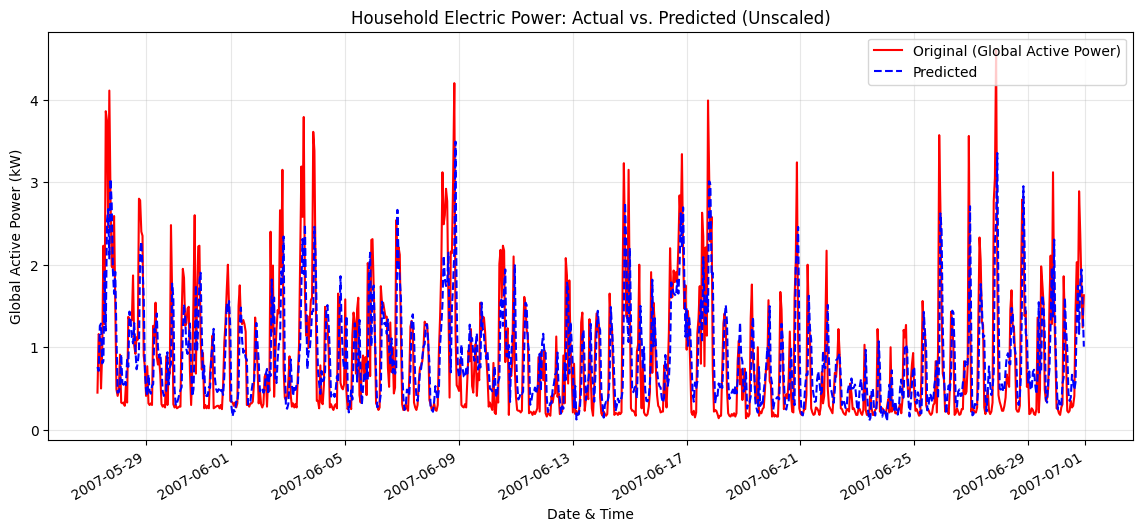

In [ ]:
n_preds = len(unscaled_predictions)
aligned_dates = dataset.index[-n_preds:]
aligned_true_power = test_data['Global_active_power'].iloc[-n_preds:].to_list()

#Plot Actual vs Predicted kW
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(aligned_dates, aligned_true_power, color='red', label='Original (Global Active Power)', linewidth=1.5)
ax1.plot(aligned_dates, unscaled_predictions, color='blue', label='Predicted', linestyle='--', linewidth=1.5)

fig.autofmt_xdate()
plt.xlabel('Date & Time')
plt.ylabel('Global Active Power (kW)')
plt.title('Household Electric Power: Actual vs. Predicted (Unscaled)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

#Transformer (Dataset 2)

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
url = "https://raw.githubusercontent.com/hinnnk/Forecasting_3/refs/heads/main/Dataset2_CLEANED_household_power_consumption_hourly.csv"
df = pd.read_csv(url)

#converting datetime to datetime format and then sorting the data by time
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

print("Dataset shape:", df.shape)

df.head()


Dataset shape: (4283, 8)


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2007-01-01 00:00:00,2.55,0.11,241.36,10.53,0.0,0.58,0.0
1,2007-01-01 01:00:00,2.52,0.07,241.10,10.44,0.0,0.00,0.0
2,2007-01-01 02:00:00,2.58,0.11,243.20,10.54,0.0,0.33,0.0
3,2007-01-01 03:00:00,2.54,0.09,243.27,10.40,0.0,0.27,0.0
4,2007-01-01 04:00:00,2.48,0.09,242.46,10.11,0.0,0.00,0.0


### Selecting features and targets

In [ ]:
#selecting the input features
features = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

#creating the input data
data = df[features]

print("Number of features:", len(features))
print("Data shape:", data.shape)

Number of features: 7
Data shape: (4283, 7)


### Split data (into training/testing sets)

In [ ]:
#split the data chronologically
train_size = int(len(data)* 0.8)

train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

Training data: (3426, 7)
Testing data: (857, 7)


### Scale the data

In [ ]:
#scale the data using the training data only
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler. transform(test_data)

print("Trainging data scaled:", train_scaled.shape)
print("Testing data scaled:", test_scaled.shape)

Trainging data scaled: (3426, 7)
Testing data scaled: (857, 7)


### Creating 24hr sequences

In [ ]:
#create sequences using the previous 24 hours
window_size = 24

def create_sequences(data, window_size):
  x = []
  y = []

  for i in range(window_size, len(data)):
    x.append(data[i-window_size:i])
    y.append(data[i,0])

  return np.array(x), np.array(y)

x_train, y_train = create_sequences(train_scaled, window_size)
x_test, y_test = create_sequences(test_scaled, window_size)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (3402, 24, 7)
y_train shape: (3402,)
x_test shape: (833, 24, 7)
y_test shape: (833,)


### Check one sequence (can remove)

In [ ]:
print("First sequence shape:", x_train[0].shape)

print("\nFirst 24-hour sequence:")
print(x_train[0])

print("\nTarget for the next hour:")
print(y_train[0])

First sequence shape: (24, 7)

First 24-hour sequence:
[[0.38548387 0.16071429 0.6470292  0.36218425 0.         0.0144819
  0.        ]
 [0.38064516 0.08928571 0.63393756 0.35884101 0.         0.
  0.        ]
 [0.39032258 0.16071429 0.73967774 0.36255572 0.         0.0082397
  0.        ]
 [0.38387097 0.125      0.74320242 0.35735513 0.         0.00674157
  0.        ]
 [0.37419355 0.125      0.70241692 0.34658247 0.         0.
  0.        ]
 [0.37419355 0.14285714 0.69687815 0.34806835 0.         0.0144819
  0.        ]
 [0.37096774 0.125      0.63997986 0.346211   0.         0.
  0.        ]
 [0.36935484 0.16071429 0.59415911 0.34695394 0.         0.01373283
  0.        ]
 [0.36774194 0.10714286 0.63595166 0.34435364 0.         0.00124844
  0.        ]
 [0.48225806 0.08928571 0.56747231 0.45579495 0.         0.
  0.64057508]
 [0.40322581 0.16071429 0.49949648 0.3833581  0.         0.0144819
  0.13205538]
 [0.39032258 0.08928571 0.44360524 0.3718425  0.         0.
  0.        ]
 [0.3

# Building Transformer

In [ ]:
#build transformer model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import GlobalAveragePooling1D

input_shape = (x_train.shape[1], x_train.shape[2])

inputs = tf.keras.Input(shape=input_shape)

#convert the input features into a larger representation
x = Dense(32)(inputs)

#transformer attention layer
attention = MultiHeadAttention(
    num_heads=2,
    key_dim=16
)(x, x)

x = LayerNormalization()(x + attention)

#feed-forward layer
feed_forward = Dense(32, activation='relu')(x)
x = LayerNormalization()(x + feed_forward)

#convert the sequence into one value
x = GlobalAveragePooling1D()(x)

x = Dropout(0.1)(x)

#output predicted Global_active_power
outputs = Dense(1)(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 32)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 32)    │      4,224 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 32)    │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24, 32)    │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,697 (22.25 KB)

 Trainable params: 5,697 (22.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [ ]:
history = model.fit(
  x_train,
  y_train,
  epochs=20,
  batch_size=32,
  validation_split=0.1,
  verbose=1
)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0694 - mae: 0.2031 - val_loss: 0.0195 - val_mae: 0.1007
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0364 - mae: 0.1494 - val_loss: 0.0181 - val_mae: 0.1018
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0307 - mae: 0.1373 - val_loss: 0.0174 - val_mae: 0.1085
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0302 - mae: 0.1365 - val_loss: 0.0179 - val_mae: 0.1035
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0276 - mae: 0.1300 - val_loss: 0.0236 - val_mae: 0.1327
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0275 - mae: 0.1303 - val_loss: 0.0173 - val_mae: 0.1067
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0273 - mae: 0.1291 - val_loss: 0.0177 - val_mae: 0.1048
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0269 - mae: 0.1285 - val_loss: 0.0192 - val_mae: 0.1021
Epoch 9/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.027

### Plot the training and validation loss (can remove)

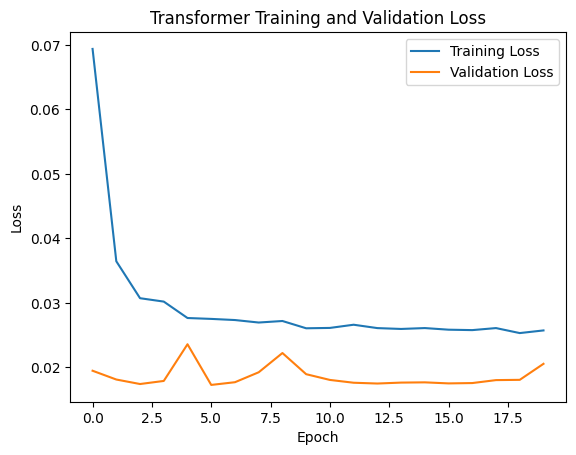

Training loss: 0.02571960538625717
Validation loss: 0.020542068406939507


In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer Training and Validation Loss')
plt.legend()
plt.show()

print("Training loss:", history.history['loss'][-1])
print("Validation loss:", history.history['val_loss'][-1])

### Make predictions

In [ ]:
#make predictions on the test data/using the trained Transformer on the test data that it DIDN'T train on
predictions = model.predict(x_test) #this line is the actual prediction step + USE this for evaluation

print("Prediction shape:", predictions.shape)

#its made 833 energy predictions, one for each test sequence

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Prediction shape: (833, 1)


## Prep 'actual' vs tranformer predictions

In [ ]:
#prepare actual values and Transformer predictions

#get the actual Global Active Power values
actual = data['Global_active_power'].iloc[train_size + window_size:].values

#convert predictions back to the original scale
predicted_scaled = predictions.flatten()

predicted = (
    predicted_scaled
    * (scaler.data_max_[0] - scaler.data_min_[0])
    + scaler.data_min_[0]
)

#create dates for the predictions
test_dates = df['datetime'].iloc[
    train_size + window_size:
].reset_index(drop=True)

#create a results dataframe
transformer_results = pd.DataFrame({
    'datetime': test_dates,
    'Global_active_power': actual,
    'prediction': predicted
})

print("Results shape:", transformer_results.shape)

transformer_results.head()

Results shape: (833, 3)


,datetime,Global_active_power,prediction
0,2007-05-27 07:00:00,0.45,0.691539
1,2007-05-27 08:00:00,1.16,0.714567
2,2007-05-27 09:00:00,1.12,0.756720
3,2007-05-27 10:00:00,0.50,0.738620
4,2007-05-27 11:00:00,0.95,0.730758


## Graph actual vs transformer predictions

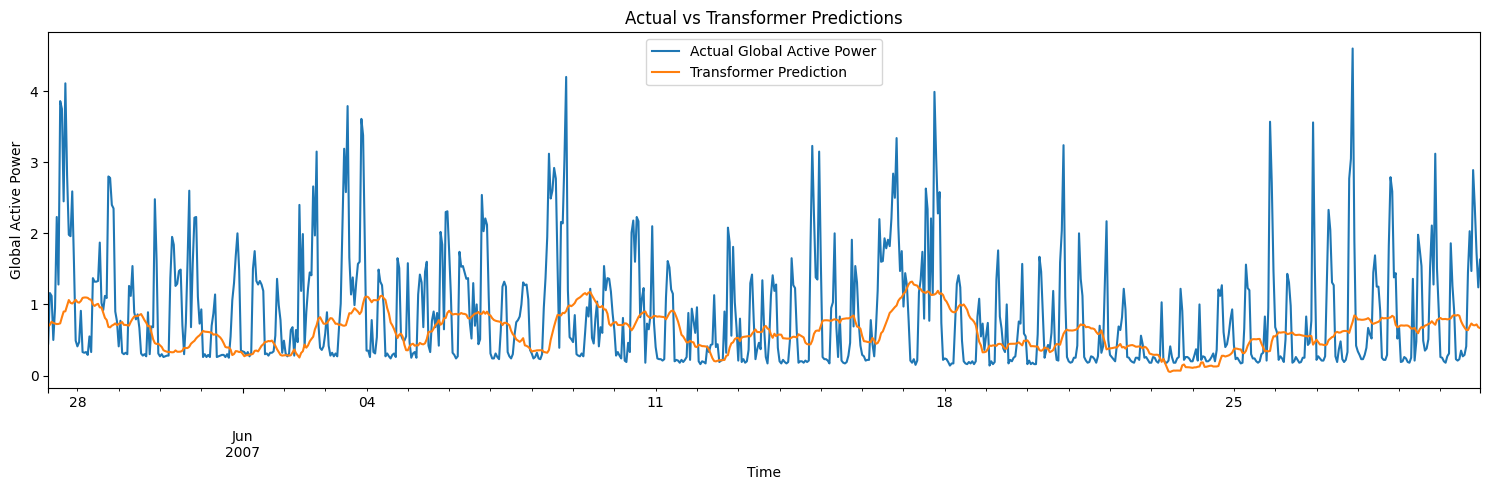

In [ ]:
#graph actual vs transformer predictions

ax = transformer_results.set_index('datetime')[
    ['Global_active_power', 'prediction']
].plot(figsize=(15, 5))

ax.set_title('Actual vs Transformer Predictions')
ax.set_xlabel('Time')
ax.set_ylabel('Global Active Power')

plt.legend(['Actual Global Active Power', 'Transformer Prediction'])

plt.tight_layout()
plt.show()

## Graph zoomed in actual vs transformer predictions

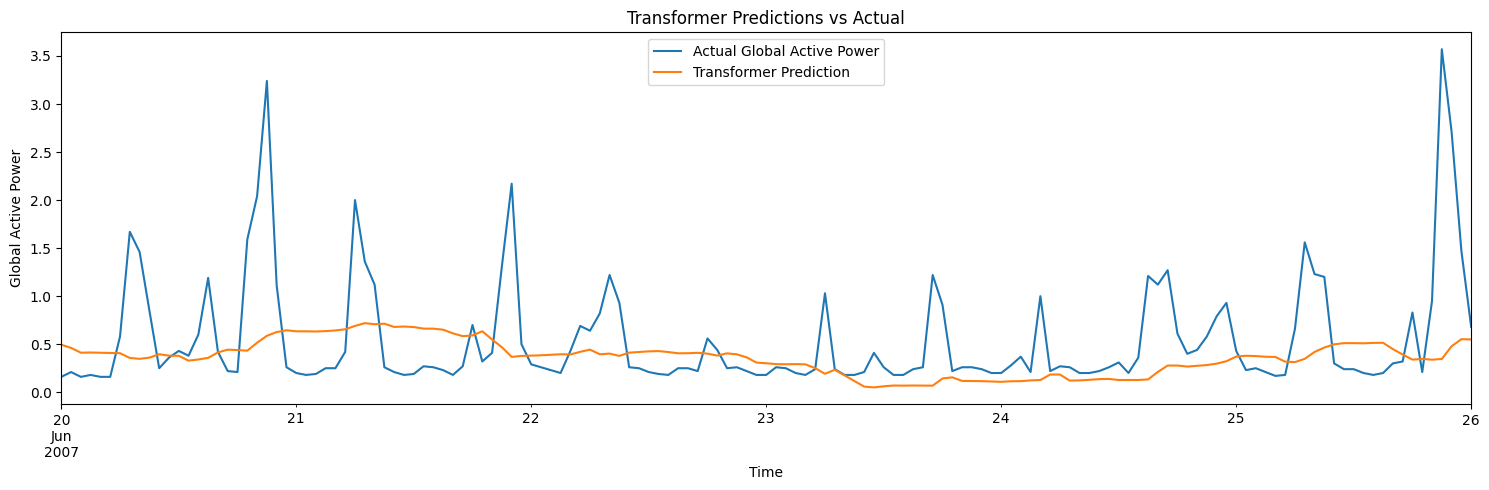

In [ ]:
#graph zoomed in actual vs Transformer predictions

zoomed = transformer_results[
    (transformer_results['datetime'] >= '2007-06-20') &
    (transformer_results['datetime'] <= '2007-06-26')
]

ax = zoomed.set_index('datetime')[
    ['Global_active_power', 'prediction']
].plot(figsize=(15, 5))

ax.set_title('Transformer Predictions vs Actual')
ax.set_xlabel('Time')
ax.set_ylabel('Global Active Power')

plt.legend(['Actual Global Active Power', 'Transformer Prediction'])

plt.tight_layout()
plt.show()

## Predicting future energy consumption (Transformer 24hrs)

In [ ]:
#get the latest 24 hours of data
last_24hrs = data.iloc[-24:].values

print("Input shape for future prediction:", last_24hrs.shape)

Input shape for future prediction: (24, 7)


In [ ]:
#Predict the next 24 hours

future_predictions = []

current_sequence = last_24hrs.copy()

for i in range(24):

    #scale the current 24-hour sequence
    current_scaled = scaler.transform(
        pd.DataFrame(current_sequence, columns=features)
    )

    #reshape for the Transformer
    current_scaled = current_scaled.reshape(1, 24, 7)

    #predict the next hour
    next_prediction_scaled = model.predict(
        current_scaled,
        verbose=0
    )[0, 0]

    #convert prediction back to original units
    next_prediction = (
        next_prediction_scaled
        * (scaler.data_max_[0] - scaler.data_min_[0])
        + scaler.data_min_[0]
    )

    future_predictions.append(next_prediction)

    #create the next row
    next_row = current_sequence[-1].copy()
    next_row[0] = next_prediction

    #move the window forward
    current_sequence = np.vstack([
        current_sequence[1:],
        next_row
    ])

print("Number of future predictions:", len(future_predictions))

Number of future predictions: 24


In [ ]:
#CREATE dates for the next 24 hours

last_datetime = df['datetime'].iloc[-1]

future_dates = pd.date_range(
    start=last_datetime + pd.Timedelta(hours=1),
    periods=24,
    freq='h'
)

print(future_dates)

DatetimeIndex(['2007-07-01 00:00:00', '2007-07-01 01:00:00',
               '2007-07-01 02:00:00', '2007-07-01 03:00:00',
               '2007-07-01 04:00:00', '2007-07-01 05:00:00',
               '2007-07-01 06:00:00', '2007-07-01 07:00:00',
               '2007-07-01 08:00:00', '2007-07-01 09:00:00',
               '2007-07-01 10:00:00', '2007-07-01 11:00:00',
               '2007-07-01 12:00:00', '2007-07-01 13:00:00',
               '2007-07-01 14:00:00', '2007-07-01 15:00:00',
               '2007-07-01 16:00:00', '2007-07-01 17:00:00',
               '2007-07-01 18:00:00', '2007-07-01 19:00:00',
               '2007-07-01 20:00:00', '2007-07-01 21:00:00',
               '2007-07-01 22:00:00', '2007-07-01 23:00:00'],
              dtype='datetime64[ns]', freq='h')


## Put predictions into a table + graph

In [ ]:
#table of the future predictions

future_forecast = pd.DataFrame({
    'datetime': future_dates,
    'predicted_Global_active_power': future_predictions
})

future_forecast.round(2)

,datetime,predicted_Global_active_power
0,2007-07-01 00:00:00,1.17
1,2007-07-01 01:00:00,1.21
2,2007-07-01 02:00:00,1.24
3,2007-07-01 03:00:00,1.27
4,2007-07-01 04:00:00,1.31
5,2007-07-01 05:00:00,1.34
6,2007-07-01 06:00:00,1.37
7,2007-07-01 07:00:00,1.38
8,2007-07-01 08:00:00,1.41
9,2007-07-01 09:00:00,1.44


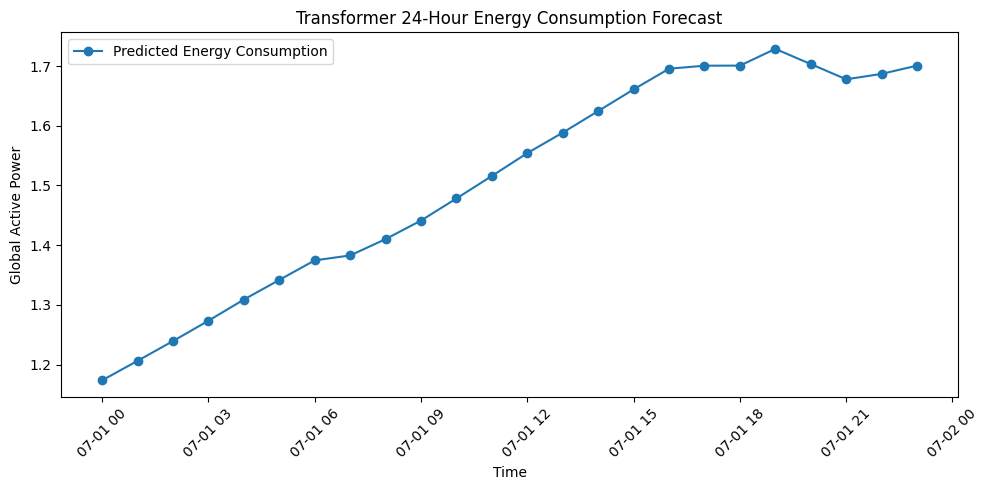

In [ ]:
#GRAPH for future energy forecast

plt.figure(figsize=(10, 5))

plt.plot(
    future_forecast['datetime'],
    future_forecast['predicted_Global_active_power'],
    marker='o',
    label='Predicted Energy Consumption'
)

plt.xlabel('Time')
plt.ylabel('Global Active Power')
plt.title('Transformer 24-Hour Energy Consumption Forecast')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()